In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw


In [ ]:
# 分子哈希
from rdkit.Chem import rdMolHash
s = Chem.MolFromSmiles('CC(C(C1=CC(=C(C=C1)O)O)O)N(C)C(=O)OCC2=CC=CC=C2')
molhashf = rdMolHash.HashFunction.names
for i, j in molhashf.items():
    print(i, rdMolHash.MolHash(s, j)) # 遍历各种hash函数看看

AnonymousGraph **1***(*(*)*(*)*(*)*(*)***2*****2)**1*
ElementGraph CC(C(O)C1CCC(O)C(O)C1)N(C)C(O)OCC1CCCCC1
CanonicalSmiles CC(C(O)c1ccc(O)c(O)c1)N(C)C(=O)OCc1ccccc1
MurckoScaffold c1ccc(CCNCOCc2ccccc2)cc1
ExtendedMurcko *c1ccc(C(*)C(*)N(*)C(=*)OCc2ccccc2)cc1*
MolFormula C18H21NO5
AtomBondCounts 24,25
DegreeVector 0,8,10,6
Mesomer CC(C(O)[C]1[CH][CH][C](O)[C](O)[CH]1)N(C)[C]([O])OC[C]1[CH][CH][CH][CH][CH]1_0
HetAtomTautomer CC(C([O])[C]1[CH][CH][C]([O])[C]([O])[CH]1)N(C)[C]([O])OC[C]1[CH][CH][CH][CH][CH]1_3_0
HetAtomProtomer CC(C([O])[C]1[CH][CH][C]([O])[C]([O])[CH]1)N(C)[C]([O])OC[C]1[CH][CH][CH][CH][CH]1_3
RedoxPair CC(C(O)[C]1[CH][CH][C](O)[C](O)[CH]1)N(C)[C]([O])OC[C]1[CH][CH][CH][CH][CH]1
Regioisomer *C.*CCC.*O.*O.*O.*OC(=O)N(*)*.C.c1ccccc1.c1ccccc1
NetCharge 0
SmallWorldIndexBR B25R2
SmallWorldIndexBRL B25R2L10
ArthorSubstructureOrder 00180019010012000600009b000000
HetAtomTautomerv2 [CH3]-[CH](-[CH](-[OH])-[C]1:[C]:[C]:[C](:[O]):[C](:[O]):[C]:1)-[N](-[CH3])-[C](=[O])-[O]-[CH2]-[c

['c1ccc(CC2CCCCC2)cc1', 'c1ccc(CC2CCCCC2)cc1', 'c1ccccc1', 'c1ccc(CC2CCCCC2)cc1', 'c1ccc(C2CCCc3ccccc32)cc1', 'c1ccc(CC2CCCCC2)cc1']
c1ccc(CC2CCCCC2)cc1


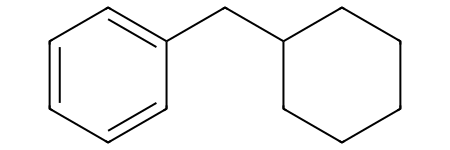

In [3]:
# Murcko Scaffold保留分子的环结构、去掉大部分的侧链取代基
import rdkit
mList = ['CCC1CC(CCC1=O)C(=O)C1=CC=CC(C)=C1','CCC1CC(CCC1=O)C(=O)C1=CC=CC=C1',\
         'CC(=C)C(C1=CC=CC=C1)S(=O)CC(N)=O','CC1=CC(=CC=C1)C(C1CCC(N)CC1)C(F)(F)F',\
         'CNC1CCC(C2=CC(Cl)=C(Cl)C=C2)C2=CC=CC=C12','CCCOC(C1CCCCC1)C1=CC=C(Cl)C=C1']
mMols = [Chem.MolFromSmiles(m) for m in mList] # 转为rdkit对象
# Calculate Murcko Scaffold Hashes
murckoHashList = [rdMolHash.MolHash(mMol, rdkit.Chem.rdMolHash.HashFunction.MurckoScaffold) for mMol in mMols] 
print(murckoHashList) # 得到分子骨架

def mostFreq(list):
    return max(set(list), key=list.count) # 不重复的列出骨架hash之后，分别计数原列表
mostFreq_murckoHash = mostFreq(murckoHashList)
print(mostFreq_murckoHash)
mostFreq_murckoHash_mol = Chem.MolFromSmiles('c1ccc(CC2CCCCC2)cc1')
mostFreq_murckoHash_mol #最频繁的分子骨架

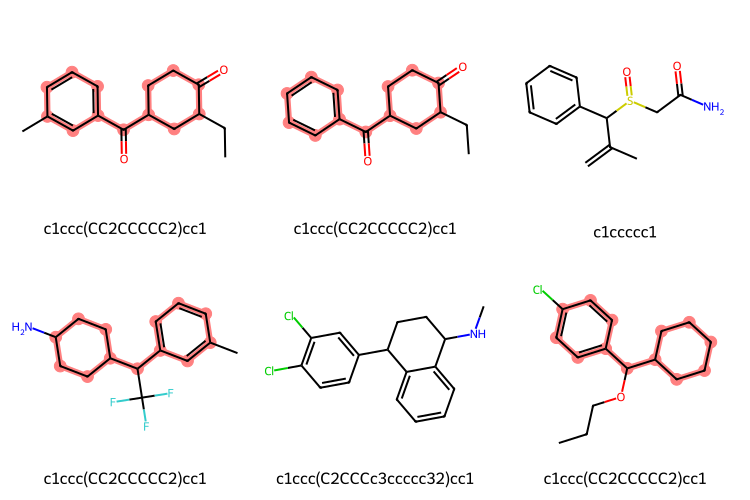

In [4]:
# 上一段的可视化展示
highlight_mostFreq_murckoHash = [mMol.GetSubstructMatch(mostFreq_murckoHash_mol) for mMol in mMols]
Draw.MolsToGridImage(mMols,legends=[murckoHash for murckoHash in murckoHashList],
                     highlightAtomLists = highlight_mostFreq_murckoHash,
                     subImgSize=(250,250), useSVG=False)

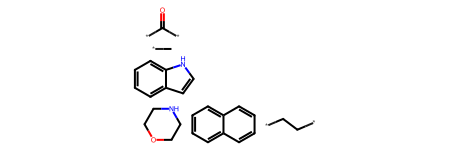

In [5]:
# 区域异构体hash
r0 = Chem.MolFromSmiles('CC1=CC2=C(C=C1)C(=CN2CCN1CCOCC1)C(=O)C1=CC=CC2=C1C=CC=C2')
r0_regioHash = rdMolHash.MolHash(r0,rdkit.Chem.rdMolHash.HashFunction.Regioisomer)
r0_regioHash_mol = Chem.MolFromSmiles(r0_regioHash)
r0_regioHash_mol # 拆解此分子的构成

In [ ]:
rList = ['CC1=CC2=C(C=C1)C(=CN2CCN1CCOCC1)C(=O)C1=CC=CC2=C1C=CC=C2',\
        'CCCCCN1C=C(C2=CC=CC=C21)C(=O)C3=CC=CC4=CC=CC=C43',\
        'CC1COCCN1CCN1C=C(C(=O)C2=CC=CC3=C2C=CC=C3)C2=C1C=CC=C2',\
         'CC1=CC=C(C(=O)C2=CN(CCN3CCOCC3)C3=C2C=CC=C3)C2=C1C=CC=C2',\
        'CC1=C(CCN2CCOCC2)C2=C(C=CC=C2)N1C(=O)C1=CC=CC2=CC=CC=C12',\
        'CN1CCN(C(C1)CN2C=C(C3=CC=CC=C32)C(=O)C4=CC=CC5=CC=CC=C54)C']
rMols = [Chem.MolFromSmiles(r) for r in rList] # 给定需要判断是否区域异构的分子集合
regioHashList = [rdMolHash.MolHash(rMol, rdkit.Chem.rdMolHash.HashFunction.Regioisomer) for rMol in rMols]

# 简单的匹配，复杂的计算全部在MolHash函数中
rmatches =[]
for regioHash in regioHashList:
    if regioHash == r0_regioHash:
        print('Regioisomer: True')
        rmatches.append('Regioisomer: True')
    else:
        print('Regioisomer: False')
        rmatches.append('Regioisomer: False')

Regioisomer: True
Regioisomer: False
Regioisomer: True
Regioisomer: True
Regioisomer: True
Regioisomer: False


In [ ]:
# 将 Regioisomer hash 片段映射回原分子：用全局非重叠匹配解决 *C、*CC* 等短片段的歧义
fragment_colors = [
    (0.90, 0.30, 0.25),
    (0.25, 0.55, 0.85),
    (0.25, 0.70, 0.45),
    (0.95, 0.65, 0.15),
    (0.65, 0.40, 0.80),
    (0.20, 0.72, 0.72),
]

def get_regioisomer_fragment_matches(mol, regio_hash):
    fragment_smiles = regio_hash.split('.')
    dummy_query = Chem.MolFromSmarts('[#0]')
    hash_fragments = [Chem.MolFromSmiles(smi) for smi in fragment_smiles]
    fragment_queries = [Chem.DeleteSubstructs(frag, dummy_query) for frag in hash_fragments] # 去掉虚拟原子

    # 对每个片段找到所有可能的匹配
    candidate_matches = []
    for smi, query in zip(fragment_smiles, fragment_queries):
        matches = {
            tuple(sorted(match))
            for match in mol.GetSubstructMatches(query, uniquify=False)
        }
        if not matches:
            raise ValueError(f'Fragment {smi!r} cannot be mapped to the molecule')
        candidate_matches.append(sorted(matches))

    # 优先放置候选最少、片段最大的查询
    search_order = sorted(
        range(len(fragment_queries)),
        key=lambda i: (len(candidate_matches[i]), -fragment_queries[i].GetNumAtoms(), i),
    )
    assignment = [None] * len(fragment_queries)
    all_atom_indices = set(range(mol.GetNumAtoms()))

    def search(depth, used_atom_indices):
        if depth == len(search_order):
            return used_atom_indices == all_atom_indices # 全部原子都要匹配

        fragment_index = search_order[depth]
        for match in candidate_matches[fragment_index]:
            match_set = set(match)
            if match_set.isdisjoint(used_atom_indices): # 切割不能重叠
                assignment[fragment_index] = match
                if search(depth + 1, used_atom_indices | match_set):
                    return True
        assignment[fragment_index] = None
        return False

    if not search(0, set()):
        raise ValueError('The hash fragments do not form a complete, non-overlapping atom mapping')

    return fragment_smiles, hash_fragments, assignment

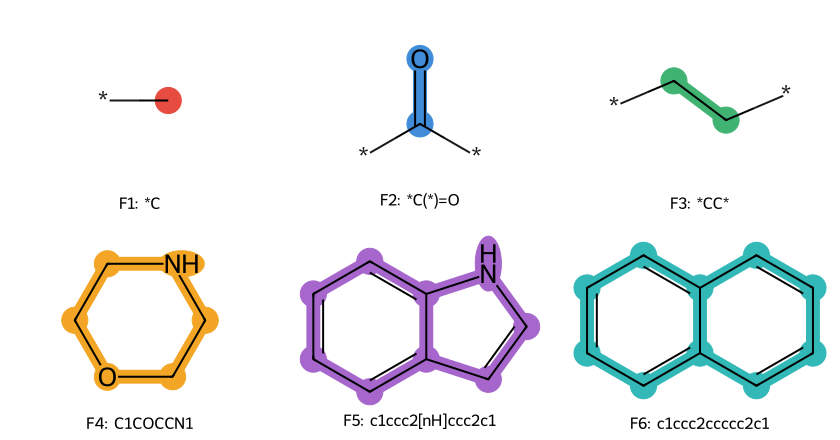

True molecule indices: [0, 2, 3, 4]


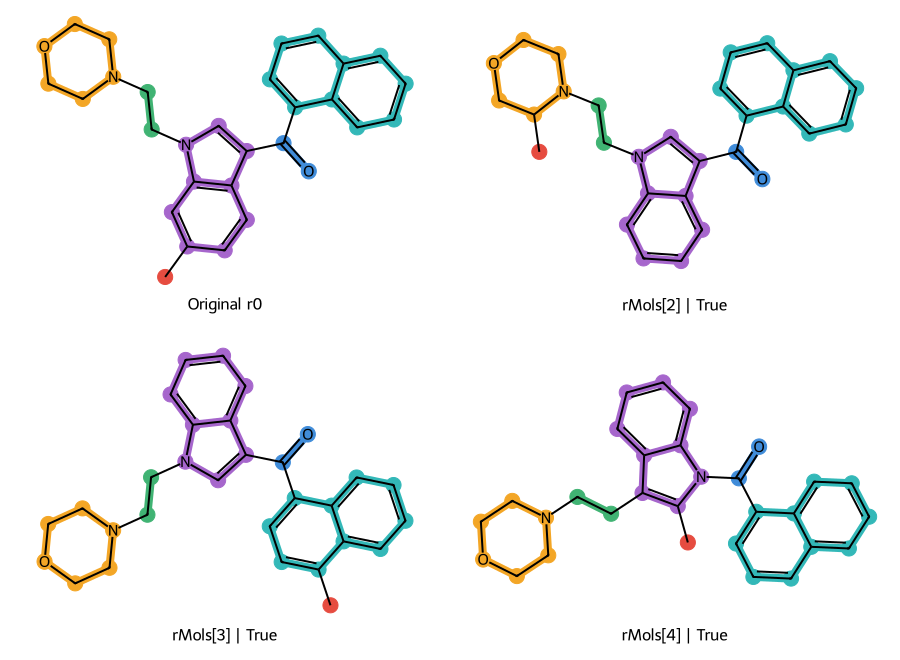

In [ ]:
# 先显示颜色与 hash 片段的对应关系
fragment_smiles, hash_fragments, _ = get_regioisomer_fragment_matches(r0, r0_regioHash)
fragment_atom_lists = []
fragment_bond_lists = []
fragment_atom_colors = []
fragment_bond_colors = []

for fragment, color in zip(hash_fragments, fragment_colors):
    real_atoms = {atom.GetIdx() for atom in fragment.GetAtoms() if atom.GetAtomicNum() != 0}
    internal_bonds = [
        bond.GetIdx() for bond in fragment.GetBonds()
        if bond.GetBeginAtomIdx() in real_atoms and bond.GetEndAtomIdx() in real_atoms
    ]
    fragment_atom_lists.append(sorted(real_atoms))
    fragment_bond_lists.append(internal_bonds)
    fragment_atom_colors.append({atom_index: color for atom_index in real_atoms})
    fragment_bond_colors.append({bond_index: color for bond_index in internal_bonds})

fragment_legend = Draw.MolsToGridImage(
    hash_fragments,
    molsPerRow=3,
    subImgSize=(280, 220),
    legends=[f'F{i + 1}: {smi}' for i, smi in enumerate(fragment_smiles)],
    highlightAtomLists=fragment_atom_lists,
    highlightBondLists=fragment_bond_lists,
    highlightAtomColors=fragment_atom_colors,
    highlightBondColors=fragment_bond_colors,
)
display(fragment_legend)

# hash匹配上的分子
true_indices = [
    i for i, regio_hash in enumerate(regioHashList)
    if regio_hash == r0_regioHash
]
comparison_indices = [i for i in true_indices if i != 0]
comparison_mols = [r0] + [rMols[i] for i in comparison_indices]
comparison_legends = ['Original r0'] + [f'rMols[{i}] | True' for i in comparison_indices]

highlight_atom_lists = []
highlight_bond_lists = []
highlight_atom_colors = []
highlight_bond_colors = []

# 利用上个定义好的函数，将这些分子切割开并染色
for mol in comparison_mols:
    _, _, fragment_matches = get_regioisomer_fragment_matches(mol, r0_regioHash) 
    atom_color_map = {}
    bond_color_map = {}

    for fragment_index, atom_indices in enumerate(fragment_matches):
        atom_set = set(atom_indices)
        color = fragment_colors[fragment_index]
        atom_color_map.update({atom_index: color for atom_index in atom_set})
        for bond in mol.GetBonds():
            if bond.GetBeginAtomIdx() in atom_set and bond.GetEndAtomIdx() in atom_set:
                bond_color_map[bond.GetIdx()] = color

    highlight_atom_lists.append(sorted(atom_color_map))
    highlight_bond_lists.append(sorted(bond_color_map))
    highlight_atom_colors.append(atom_color_map)
    highlight_bond_colors.append(bond_color_map)

print(f'True molecule indices: {true_indices}')
Draw.MolsToGridImage(
    comparison_mols,
    molsPerRow=2,
    subImgSize=(450, 330),
    legends=comparison_legends,
    highlightAtomLists=highlight_atom_lists,
    highlightBondLists=highlight_bond_lists,
    highlightAtomColors=highlight_atom_colors,
    highlightBondColors=highlight_bond_colors,
)